# Assignment 5

Previously we have looked at the effects of uncertainties in the model parameters and the input. Now, what is left, is the uncertainty in the model output, that is, how does the model behave when changing the calibration data (i.e. the discharge values of the time series).

## Why would the discharge be uncertain?

There are several reasons why this is the case. Of course, measurement errors play a role in changing the observed value from the real one. These errors can, again, be due to more severe errors, like a false calibration or human error, or just the regular noise.

The measured value itself, like stated above, is also not the discharge itself, but the river depth, by which the discharge is then calculated. This leads to another layer of uncertainty, because this calculation is not through a universal formula that holds true for every river or cross section, but a specific so called rating curve. The used rating curve itself is only one possible realisation of the process of fitting a function to the data points. It can also be imprecise, when the data points are outdated. In that case the cross-section could have changed, or the flow conditions could have been changed up- or downs-stream of the cross-section, which would lead to different flow conditions at the cross section and therby a different rating curve. Another issue for the rating curve are the lack of data points for extreme events, which have to be extrapolated.

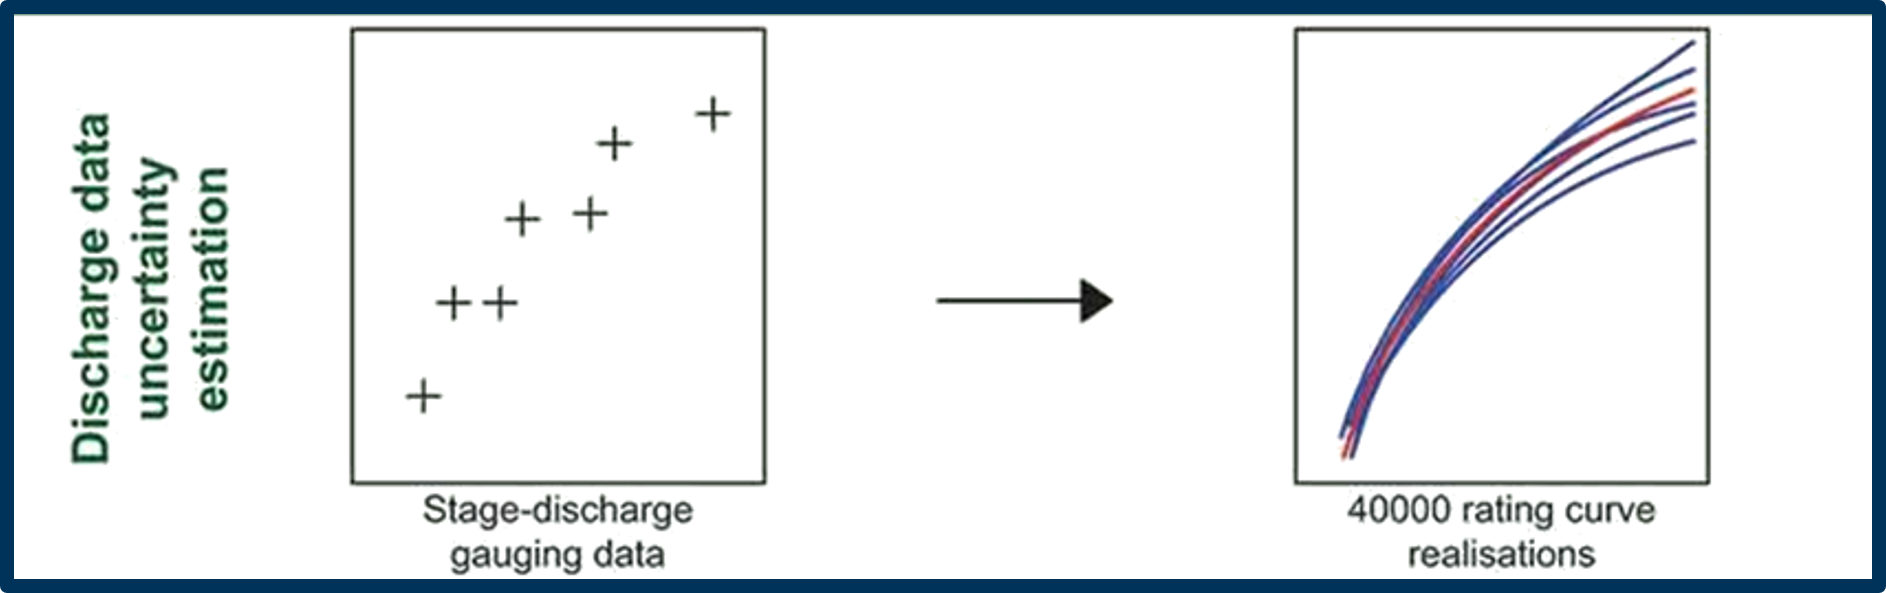
Rating curve uncertainty. From Hydrological model calibration with uncertain discharge data, by Westerberg et al., 2020

## Theory

To assess the effect of the uncertainty in the output, we will perturb the time series like in the previous assignment, only this time, it will be the depth. However, first we are going to fit a rating curve to the data points (i.e. the given discharge values over the depth), so that we can later calculate the new discharges for the new depths. Here we show three different approaches: a database, a polynomial fit and a linear regression in logspace. For the results we will only use the last two approaches.

### Database Method

The idea is to use the provided depth-discharge-pairs as a look-up table for the perturbed depths. Here is an excerpt of the time series again:

In [11]:
import pandas
dataframe = pandas.read_csv('time_series___24163005.csv', sep=';', nrows=10)
dataframe

,Unnamed: 0,tavg__ref,pptn__ref,petn__ref,diso__ref,ddho__ref
0,2010-11-01-00,7.649465,0.0,0.03566,4.21,163.0
1,2010-11-01-01,6.724136,0.0,0.03130,4.21,163.0
2,2010-11-01-02,6.004804,0.0,0.02802,4.21,163.0
3,2010-11-01-03,5.880548,0.0,0.02745,4.21,163.0
4,2010-11-01-04,5.305698,0.0,0.02464,4.21,163.0
5,2010-11-01-05,4.899967,0.0,0.02268,4.21,163.0
6,2010-11-01-06,4.836225,0.0,0.02240,4.21,163.0
7,2010-11-01-07,4.883360,0.0,0.02264,4.21,163.0
8,2010-11-01-08,6.138680,0.0,0.02860,4.21,163.0
9,2010-11-01-09,7.931963,0.0,0.03718,4.21,163.0


Of interest are here the columns "diso_ref" and "ddho_ref".

In [10]:
dataframe.iloc[:, -2:]

,diso__ref,ddho__ref
0,4.21,163.0
1,4.21,163.0
2,4.21,163.0
3,4.21,163.0
4,4.21,163.0
5,4.21,163.0
6,4.21,163.0
7,4.21,163.0
8,4.21,163.0
9,4.21,163.0


After perturbing the depths we search for the new values in the database and get a corresponding discharge value. 

There are some problems with this approach. First, we have to not only extrapolate values that are bigger or smaller than what we can find in the database, but there is also a need to interpolate the values of the database, since it is discrete and therefore the perturbed values can lie outside of the known value-pairs. Therefore we will take a look at the other approaches.

### Piecewise Polynomial

If we want a continous function, unlike our discrete database, there are several options. One is a simple polynomial. However, the given data points can not be fitted with a regular polynomial, which is why we need a piecewise polynomial. The two polynomials $ f(x) $ and $ g(x) $ will each be fitted to a section of the data series, specifically,  $ f(x) $ from the smallest ddho_ref value to the split-point $ x_{s} $ and $ g(x) $ from $ x_{s} $ to the largest value of ddho_ref.

Now we have to ensure that the polynomials are smooth at $ x_{s} $ (i.e. the first derivative and the height at $ x_{s} $ should be the same). This can be done the following way: we let $ f(x) $ stay the same while we multiply $ g(x) $ with a factor $ a $. Where $ a $ is: $$ a = \frac{f'(x_{s})}{g'(x_{s})} $$ This then ensures that, when we differentiate $ a * g(x) $, the value of $ g'(x_{s}) $ will be the same as $ f'(x_{s}) $: $$ g'(x_{s}) = \frac{f'(x_{s})}{g'(x_{s})} * g'(x_{s}) = f'(x_{s}) $$ Lastly, there is still a need for the correct height $ c $, which we will add to the polynomial, so that the two functions have the same value at $ x_{s} $. $ c $ is then simply the difference between the two polynomials at  $ x_{s} $: $$ c = f(x_{s}) - a * g(x_{s}) $$ The resulting piecewise polynomial $ h(x) $ then looks like this: 

$$ h(x)=   \left\{
\begin{array}{ll}
      a * g(x) + c & x>x_{s} \\
      f(x) & x \le x_{s} \\
\end{array} 
\right.  $$

The challenges with this approach are identifying the change point $ x_{s} $ and ensruing that $ h(x) $ is always convex at the extrapolated high-flow events. Let's take a look now on the last approach.

### Linear Regression in Logspace

Another possible approach is to regress the data points linearly in logspace. However, since the data points do not reflect a linear function in logspace, here too a piecewise approach is needed with change points $ x_{1} $ and $ x_{2} $. Because the discharge does not start at a depth of 0 a offset $ c $ has to be implemented. The data series is then split at these change points giving us three seperat data series. These data series are then transformed into log space and a subsqequent linear regression follows.

After the rating curve is fitted, the depths can be perturbed from which the resulting discharge can be then calculated. We do this 2,000 times, similar to the previous assignment. We then let the model run, first with the original depth and the resulting rating curve values, to see what impact the rating curve itself has one the mdoel performance. Then we let the model run with the perturbed series and after that recalibrate it to see the difference.

## Implementation

### Database Method

In [ ]:
def build_diso_from_ddho(df):
    grouped = (
        df.groupby("ddho__ref")["diso__ref"]
          .mean()          # to get a single discharge value per depth
          .sort_index()
    ) # you index trough depth and then assign the according discharges (the mean of it)
    depths = grouped.index.to_numpy()
    discharges = grouped.to_numpy()
    # f(depth(t)) = discharge(t) -> get discharge as a fct of depth independent of time
    def f(ddho):
        idx = np.abs(depths - ddho).argmin()
        return discharges[idx]

    return f

### Piecewise Polynomial

In [ ]:
def build_diso_from_ddho(df):
    xs = 430.5
    df = df.copy()
    df.sort_values(by='ddho__ref', inplace=True)
    # Splitting data
    first_intervall = df[df['ddho__ref'] <= xs]
    second_intervall = df[df['ddho__ref'] >= xs]

    # Polynomial fit
    d = np.linspace(df['ddho__ref'].min(),
                    df['ddho__ref'].max(), 1000)

    fit_first = np.polyfit(first_intervall['ddho__ref'],
                           first_intervall['diso__ref'], deg=6)

    a_first, b_first, c_first, d_first, e_first, f_first, g_first = fit_first
    Q_first = a_first * d**6 + b_first * d**5 + c_first * d**4 + \
        d_first * d**3 + e_first * d**2 + f_first * d + g_first

    fit_second = np.polyfit(second_intervall['ddho__ref'],
                            second_intervall['diso__ref'], deg=6)

    Q_second = fit_second[0] * d**6 + fit_second[1] * d**5 + fit_second[2] * d**4 + \
        fit_second[3] * d**3 + fit_second[4] * \
        d**2 + fit_second[5] * d + fit_second[6]

    # Smoothing the polynomials
    p1 = np.poly1d(fit_first)
    p2 = np.poly1d(fit_second)

    dp1 = np.polyder(p1)
    dp2 = np.polyder(p2)

    den = dp2(xs)
    if np.isclose(den, 0.0, atol=1e-12):
        raise ValueError(
            "Derivative at the joining point is zero, cannot recalibrate.")

    a = dp1(xs) / den
    c = p1(xs) - a * p2(xs)

    # def Q(x):
    #     x = np.asarray(x, dtype=float)
    #     return np.where(x <= xs, p1(x), a * p2(x) + c)

    return fit_first, fit_second, a, c

### Linear Regression in Logspace

In [ ]:
def build_diso_from_ddho(df):
    """Fit piecewise power-law rating curve using LinearRegression in log-space with THREE segments."""
    from sklearn.linear_model import LinearRegression
    
    # Hard-coded parameters from optimized fit
    c_hardcoded = 95.0
    h_break1 = 200.0
    h_break2 = 440.0
    
    df = df.copy()
    df.sort_values(by='ddho__ref', inplace=True)
    
    # Segment 1: heights <= h_break1
    seg1_mask = df['ddho__ref'] <= h_break1
    h_seg1 = df[seg1_mask]['ddho__ref'].values
    q_seg1 = df[seg1_mask]['diso__ref'].values
    
    delta_h1 = h_seg1 - c_hardcoded
    if np.any(delta_h1 <= 0):
        delta_h1 = np.maximum(delta_h1, 1e-6)
    
    log_h1 = np.log(delta_h1)
    log_q1 = np.log(q_seg1)
    
    X1 = log_h1.reshape(-1, 1)
    model1 = LinearRegression()
    model1.fit(X1, log_q1)
    
    ln_a1 = model1.intercept_
    b1 = model1.coef_[0]
    a1 = np.exp(ln_a1)
    
    # Segment 2: h_break1 < heights < h_break2
    seg2_mask = (df['ddho__ref'] > h_break1) & (df['ddho__ref'] < h_break2)
    h_seg2 = df[seg2_mask]['ddho__ref'].values
    q_seg2 = df[seg2_mask]['diso__ref'].values
    
    delta_h2 = h_seg2 - c_hardcoded
    if np.any(delta_h2 <= 0):
        delta_h2 = np.maximum(delta_h2, 1e-6)
    
    log_h2 = np.log(delta_h2)
    log_q2 = np.log(q_seg2)
    
    X2 = log_h2.reshape(-1, 1)
    model2 = LinearRegression()
    model2.fit(X2, log_q2)
    
    ln_a2 = model2.intercept_
    b2 = model2.coef_[0]
    a2 = np.exp(ln_a2)
    
    # Segment 3: heights >= h_break2
    seg3_mask = df['ddho__ref'] >= h_break2
    h_seg3 = df[seg3_mask]['ddho__ref'].values
    q_seg3 = df[seg3_mask]['diso__ref'].values
    
    delta_h3 = h_seg3 - c_hardcoded
    if np.any(delta_h3 <= 0):
        delta_h3 = np.maximum(delta_h3, 1e-6)
    
    log_h3 = np.log(delta_h3)
    log_q3 = np.log(q_seg3)
    
    X3 = log_h3.reshape(-1, 1)
    model3 = LinearRegression()
    model3.fit(X3, log_q3)
    
    ln_a3 = model3.intercept_
    b3 = model3.coef_[0]
    a3 = np.exp(ln_a3)
    
    # Return segments with power-law parameters
    fit_first = {'a': a1, 'b': b1, 'c': c_hardcoded, 'h_break': h_break1}
    fit_second = {'a': a2, 'b': b2, 'c': c_hardcoded, 'h_break': h_break2}
    fit_third = {'a': a3, 'b': b3, 'c': c_hardcoded}
    
    print(f"Built 3-segment rating curve:")
    print(f"  Segment 1 (h≤{h_break1}): Q = {a1:.4f}*(h-{c_hardcoded})^{b1:.4f}")
    print(f"  Segment 2 ({h_break1}<h<{h_break2}): Q = {a2:.4f}*(h-{c_hardcoded})^{b2:.4f}")
    print(f"  Segment 3 (h≥{h_break2}): Q = {a3:.4f}*(h-{c_hardcoded})^{b3:.4f}")
    
    return fit_first, fit_second, fit_third

### Perturbation

The perturbation is a uniform distribution from -5 centimeters to 5 centimeters in this example, however we also did one from -15 centimeters to 15 centimeters.

In [ ]:
def perturbed_ddho(ddho):
    #values = np.linspace(-5, 5, 11)
    perturbation = np.random.uniform(-5, 5, size=len(ddho))
    ddho_perturbed = ddho + perturbation
    return ddho_perturbed

## Results

As explained, we will only take a closer look at the piecewise polynomial and the linear regression in logspace.

First let's take a look at what the effect of the perturabtion looks like, with two randomly chosen simulations:

For 5 cm:

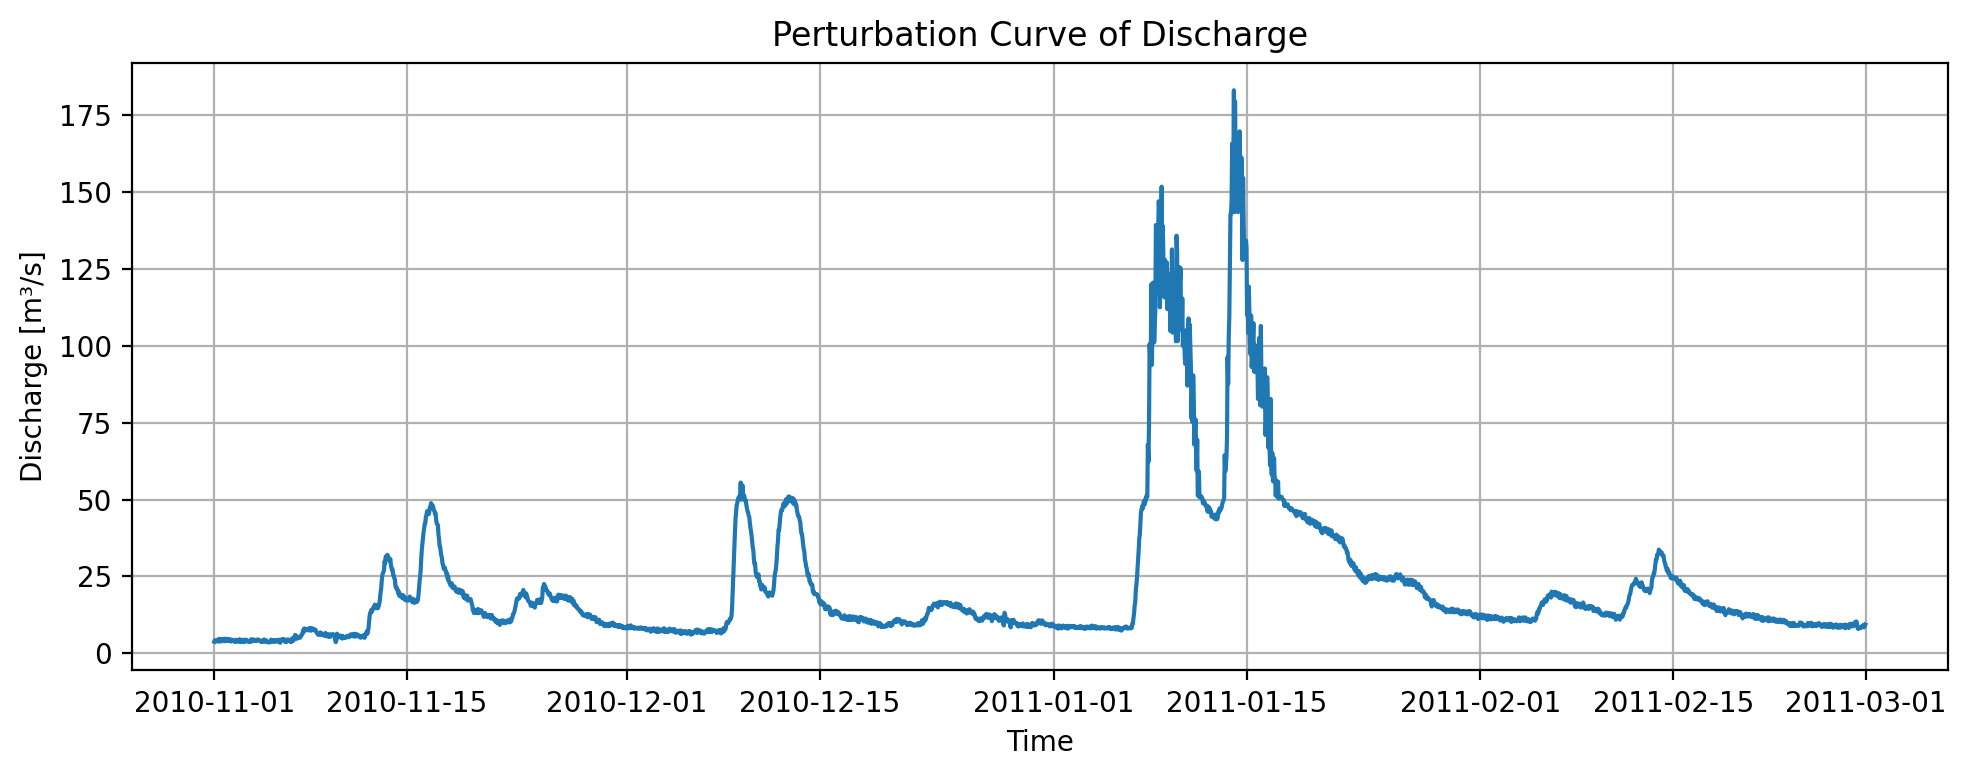

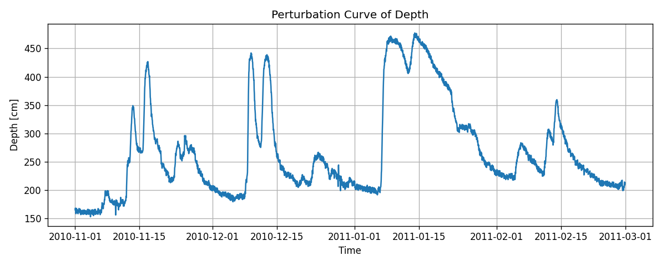

For 15 cm:

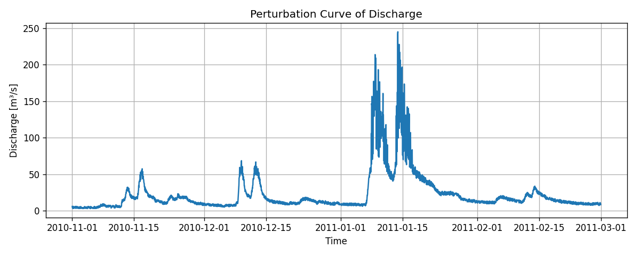

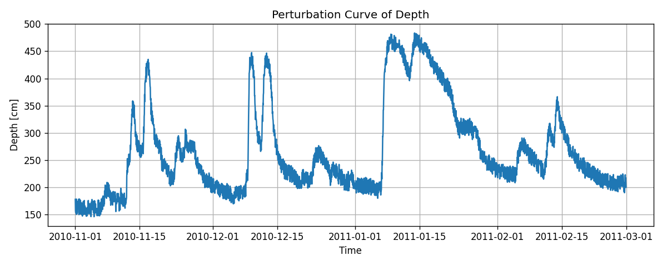

Obviously the larger amount of perturbation in the 15 cm graph reflects in the bigger band widths, however, interestingly, the discharge varies especially at the peaks. This is due to the discharge getting more sensitive (i.e. the rating curve having a greater derivative, or steeper slope) at the higher values.

### Piecewise Polynomial

Here are the resulting OFV graphs as scaterplots and CDFs:

For 5 cm:

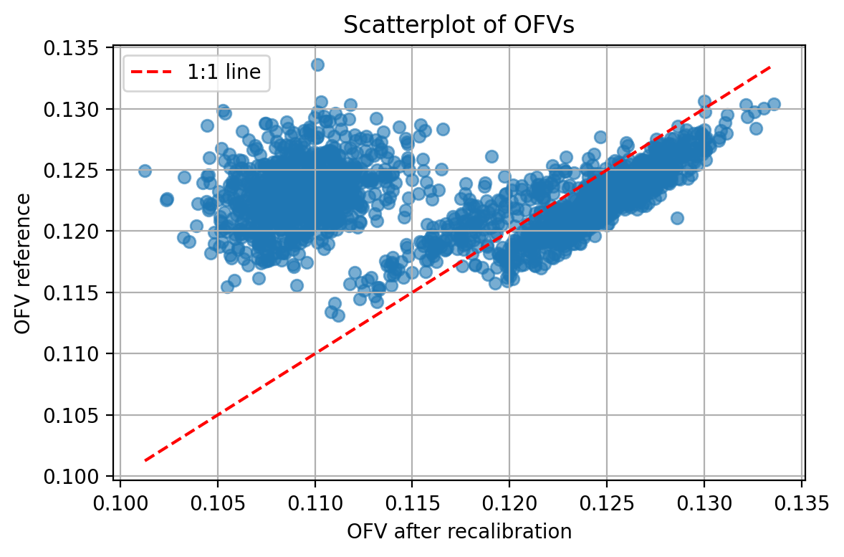

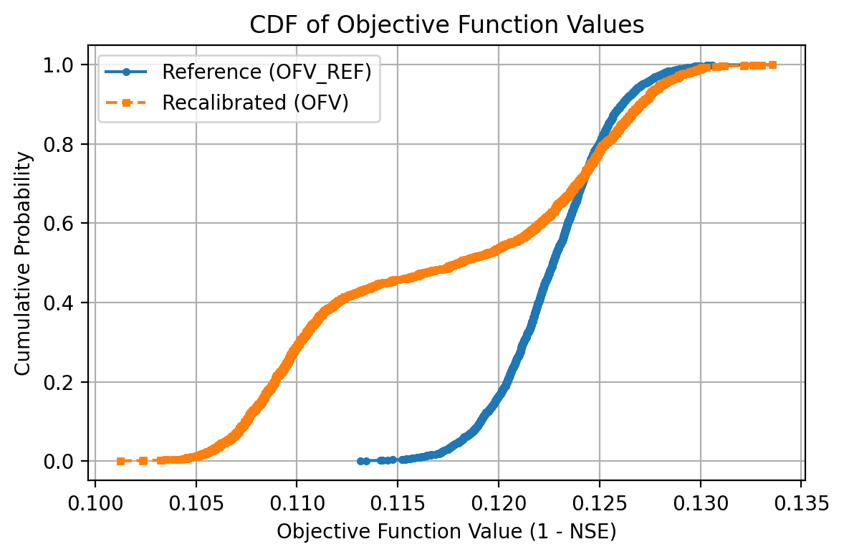

For 15 cm:

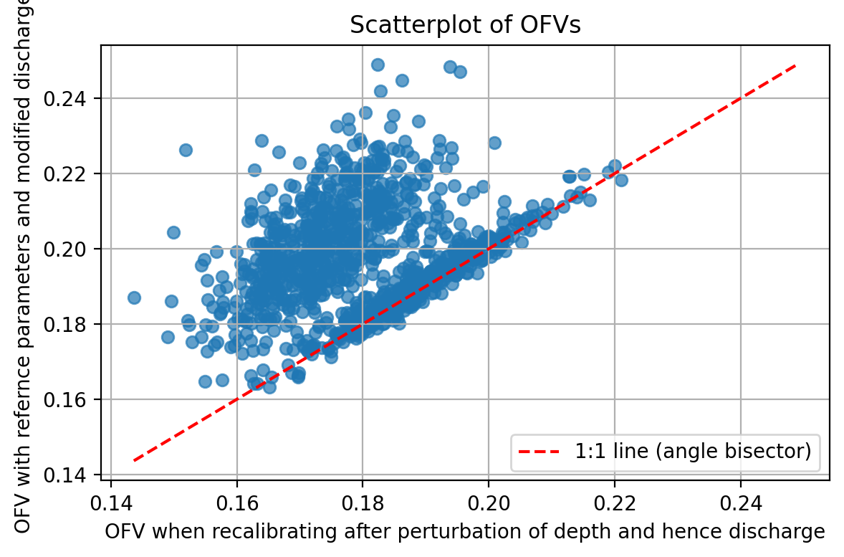

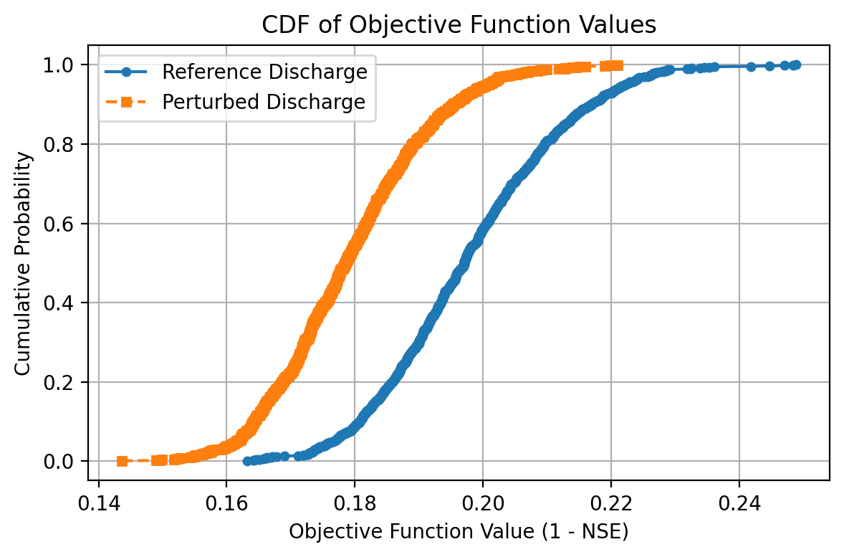

Notable for the 5 centimeter perturbation are the two groups in the scatterplot and the two slopes in the CDS resulting from local minima. One can also see that the recalibration betters the result of the OFV.

Now for the parameter values for 5 centimeter perturbation:

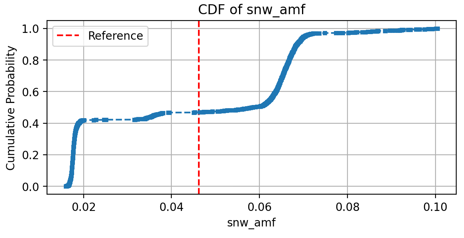

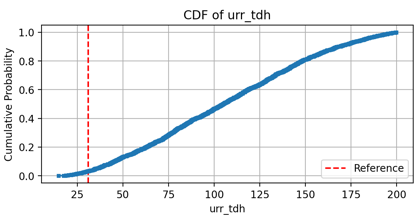

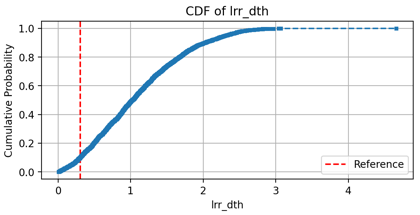

Some parameters like the snow melt/fall temperature or the permanent wilting point show two denser regions. This has probably something to do with the local minima seen in the scatter plot. Then there are other, who seem to be insensitive, like upper-reservoir threshold depth or the lower-reservoir depth.

The rating curve itself worsens the performance of the OFV from 0.092356 to 0.115338.

### Linear Regression in Logspace

Here are the OFV graphs for a 5 centimeter perturbation:

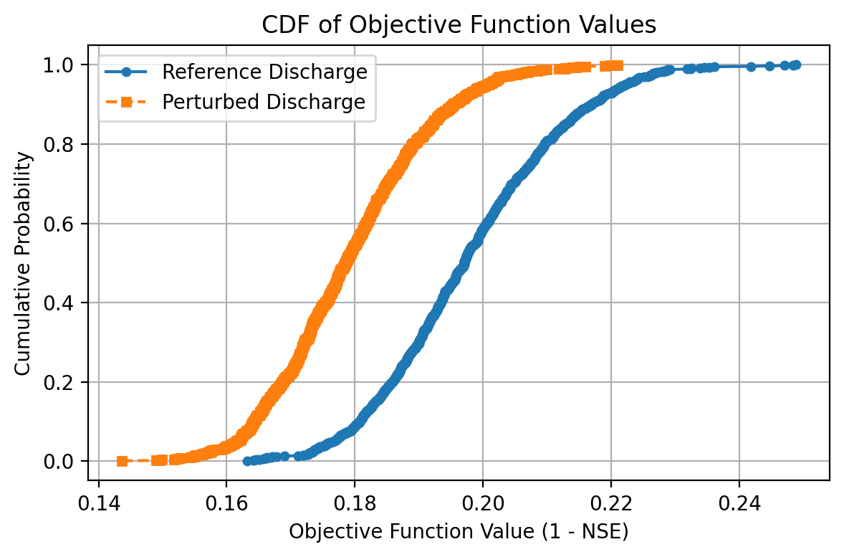

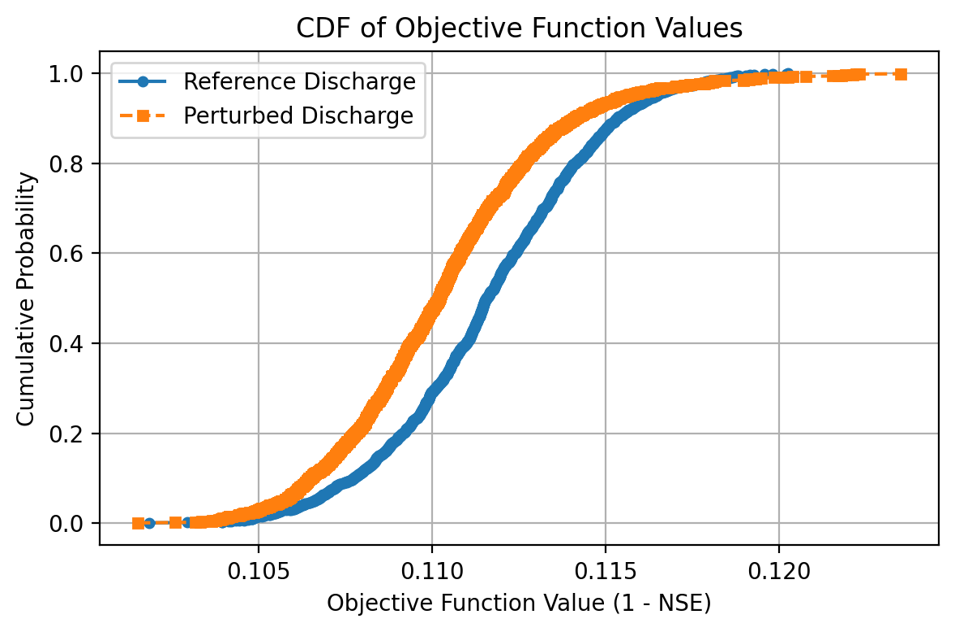

Like with the piecewise polynomial, naturally, the calibrated models perform better overall than the uncalibrated ones.

The rating curve itself worsens the performance of the OFV from 0.092356 to 0.101956.

We can see from the obtained data that even a small change perturbation to the depth ( a maximum of 5 centimeters to a depth always greater than 150 centimeters) results in a relativly large degradation of the OFV (0.092 to 0.101956).

## Connection to previous assignments

As explained in the previous assignment, the sensitivity observed here is not the same as with the local and global sensitivity. We are observing a sensitivity of the parameters to a change in the calibration data and measure how well the model can adjust to different discharge data. It is also important to note the effect of the rating curve. As explained, we have another layer of obfuscation due to this.

When looking at the OFVs of the model even after recalibration, they are siginficantly worse than the ones from Assignment 4, where we changed the input (i.e. the precipitation). 

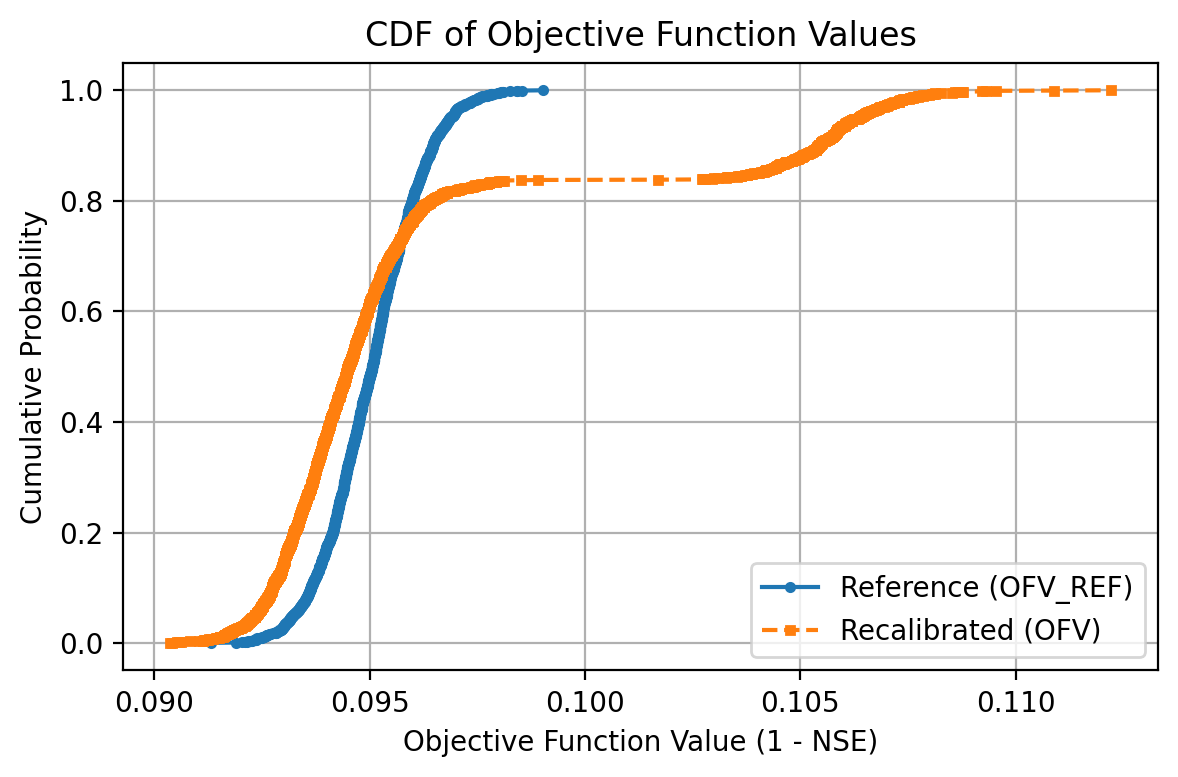

The rating curve, as shown, itself leads to a significant worsening of the OFV. It is therefore not just the unreliability of the model, when it comes to different discharges. 

When we look at the different modules the parameters do seem to react differently.

### Snow module

All non-stationary parameters of the snow module seem to be split up into the two minimas, unlike in previous assigments. However, due to the nature of the model it is not possible to exactly determine the reason for this. It could be that the different flow, along with the given precipitation force the model to allign how much snow is stored versus how much is going to the runoff. Especially the snow fall/melt temperature is sensitive like in the other assignments.

### Soil module

The soil module shows very similar results, when compared to previous assignments.

### Upper reservoir

The upper reservoir also shows a high sensitivity in the upper-to-lower coefficient, the discharge-to-runoff coefficient and the runoff coefficient. This is in agreement to previous assignemnts showing the upper reservoir as having a low impact, which the value of these parameters guarantee.

### Lower reservoir

Here too, the results show the same as the previous assignemnts, giving a high importance on these parameters and, except for the inital depth, which, again, can be changed in the runtime of the model.
